# Lab: Parquet, DuckDB, Polars and Arrow with MovieLens 100K (Colab)

Run this notebook in **Google Colab** (see `Setup Google Colab.md` in the Labs folder).
Start with **0. Setup**, which installs the packages and downloads the data.

In seven short steps:

1. Convert CSV files to **Parquet** with DuckDB.
2. Query the Parquet files directly with **DuckDB** SQL.
3. Transform data with **Polars** and query it from DuckDB through **Arrow**.
4. Read Parquet **lazily** with Polars and see which columns are read.
5. Save tables in a **DuckDB database file** and reopen it.
6. **Conhecer o dataset (EDA)**: info, head, describe, nulos, tipos de variáveis e gráficos.
7. Responder a **quatro perguntas** em Python (Polars) e em SQL (DuckDB).

**Data:** MovieLens `ml-latest-small` (100,836 ratings, 9,742 movies).

## 0. Setup

In [1]:
# Install the package versions used in the labs (takes a few seconds).
# You can ignore the message "you may need to restart the kernel".
%pip install -q "duckdb>=1.4" "polars>=1.37"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.8/865.8 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.4 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import urllib.request, zipfile
import duckdb
import polars as pl

# Download the MovieLens data into this Colab session (only the first time)
if not Path('ml-latest-small/ratings.csv').exists():
    urllib.request.urlretrieve('https://files.grouplens.org/datasets/movielens/ml-latest-small.zip',
                               'ml-latest-small.zip')
    zipfile.ZipFile('ml-latest-small.zip').extractall('.')

CSV_DIR = Path('ml-latest-small')   # the CSV files
PQ_DIR = Path('parquet')            # the Parquet files we create
OUT_DIR = Path('output')            # the DuckDB database
PQ_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

print('DuckDB', duckdb.__version__, '| Polars', pl.__version__)

DuckDB 1.5.6 | Polars 1.44.2


## 1. Convert CSV to Parquet

One DuckDB `COPY` statement reads a CSV file and writes it as Parquet. Parquet stores each column
separately, compressed, together with its data type.

In [3]:
for table in ['ratings', 'movies', 'tags', 'links']:
    csv_file = CSV_DIR / f'{table}.csv'
    parquet_file = PQ_DIR / f'{table}.parquet'
    duckdb.execute(f"COPY (SELECT * FROM '{csv_file.as_posix()}') TO '{parquet_file.as_posix()}' (FORMAT parquet)")

    csv_kb = csv_file.stat().st_size / 1024
    parquet_kb = parquet_file.stat().st_size / 1024
    print(f'{table:8} CSV {csv_kb:5.0f} KB  ->  Parquet {parquet_kb:5.0f} KB  ({parquet_kb / csv_kb:.0%})')

ratings  CSV  2426 KB  ->  Parquet   676 KB  (28%)
movies   CSV   483 KB  ->  Parquet   245 KB  (51%)
tags     CSV   116 KB  ->  Parquet    50 KB  (43%)
links    CSV   193 KB  ->  Parquet   137 KB  (71%)


## 2. Query the Parquet files directly with DuckDB

DuckDB reads the files where they are: there is nothing to import and no server to start.
`.pl()` returns the result as a Polars DataFrame.

In [11]:
RATINGS = (PQ_DIR / 'ratings.parquet').as_posix()
MOVIES = (PQ_DIR / 'movies.parquet').as_posix()

top10 = duckdb.sql(f"""
    SELECT m.title, ROUND(AVG(r.rating), 2) AS avg_rating, COUNT(*) AS num_ratings
    FROM '{RATINGS}' r
    JOIN '{MOVIES}' m USING (movieId)
    GROUP BY m.movieId, m.title
    HAVING COUNT(*) >= 100              -- only movies with at least 100 ratings
    ORDER BY AVG(r.rating) DESC         -- the exact average, not the rounded one
    LIMIT 10
""").pl()
top10

title,avg_rating,num_ratings
str,f64,i64
"""Shawshank Redemption, The (199…",4.43,317
"""Godfather, The (1972)""",4.29,192
"""Fight Club (1999)""",4.27,218
"""Godfather: Part II, The (1974)""",4.26,129
"""Departed, The (2006)""",4.25,107
"""Goodfellas (1990)""",4.25,126
"""Casablanca (1942)""",4.24,100
"""Dark Knight, The (2008)""",4.24,149
"""Usual Suspects, The (1995)""",4.24,204


## 3. Transform with Polars, query with DuckDB (through Arrow)

Polars splits the `genres` column (`Adventure|Animation|...`) into one row per genre. The result,
`movie_genres`, exists only in memory, not in a file. DuckDB queries it by its variable name: both
tools use the Arrow columnar format, so the data is not copied or converted.

In [12]:
movie_genres = (
    pl.read_parquet(MOVIES)
      .select('movieId', pl.col('genres').str.split('|').alias('genre'))
      .explode('genre', empty_as_null=True)
)

genre_counts = duckdb.sql(f"""
    SELECT g.genre, COUNT(*) AS num_ratings, ROUND(AVG(r.rating), 2) AS avg_rating
    FROM movie_genres g                  -- a Polars DataFrame
    JOIN '{RATINGS}' r USING (movieId)   -- a Parquet file
    GROUP BY g.genre
    ORDER BY num_ratings DESC
""").pl()
genre_counts

genre,num_ratings,avg_rating
str,i64,f64
"""Drama""",41928,3.66
"""Comedy""",39053,3.38
"""Action""",30635,3.45
"""Thriller""",26452,3.49
"""Adventure""",24161,3.51
…,…,…
"""Musical""",4138,3.56
"""Western""",1930,3.58
"""Documentary""",1219,3.8


## 4. Read Parquet lazily with Polars

`pl.read_parquet` reads the whole file at once (**eager**). `pl.scan_parquet` reads nothing yet: it
builds a plan (**lazy**), and `.collect()` runs it. `.explain()` shows what the plan will read.

In [13]:
lazy_query = (
    pl.scan_parquet(RATINGS)
      .filter(pl.col('rating') >= 4.5)
      .select('movieId', 'rating')
)
print(lazy_query.explain())

Parquet SCAN [parquet/ratings.parquet]
PROJECT 2/4 COLUMNS
SELECTION: col("rating") >= 4.5
ESTIMATED ROWS: 100836


In the plan, `PROJECT 2/4 COLUMNS` means only 2 of the 4 columns are read from the file, and
`SELECTION` means the filter is applied while reading. Parquet makes this possible because it stores
each column separately.

In [14]:
high_ratings = lazy_query.collect()   # the file is read now
high_ratings.shape

(21762, 2)

## 5. Save tables in a DuckDB database file

A file name instead of memory keeps the tables after Python closes. `with` closes the connection at
the end of the block: an open `.duckdb` file is locked, and no other program can open it.

In [15]:
DB = (OUT_DIR / 'movielens.duckdb').as_posix()

with duckdb.connect(DB) as db:
    db.execute(f"CREATE OR REPLACE TABLE ratings AS SELECT * FROM '{RATINGS}'")
    db.execute(f"CREATE OR REPLACE TABLE movies AS SELECT * FROM '{MOVIES}'")
    db.execute("CREATE OR REPLACE TABLE genre_counts AS SELECT * FROM genre_counts")   # from Polars

# Reopen it, as in a future session
with duckdb.connect(DB, read_only=True) as db:
    print(db.sql('SHOW TABLES'))
    print(db.sql('SELECT COUNT(*) AS ratings FROM ratings'))

┌──────────────┐
│     name     │
│   varchar    │
├──────────────┤
│ genre_counts │
│ movies       │
│ ratings      │
└──────────────┘

┌─────────┐
│ ratings │
│  int64  │
├─────────┤
│  100836 │
└─────────┘



## 6. Conhecer o dataset (EDA)

Antes de responder a perguntas, convém conhecer as tabelas: dimensão, tipos de dados, primeiras linhas,
estatísticas descritivas, valores em falta, tipo de cada variável e a forma das distribuições.
Sempre que possível, cada passo é feito em **Python (Polars)** e em **SQL (DuckDB)**.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

TAGS = (PQ_DIR / 'tags.parquet').as_posix()
LINKS = (PQ_DIR / 'links.parquet').as_posix()

ratings = pl.read_parquet(RATINGS)
movies = pl.read_parquet(MOVIES)
tags = pl.read_parquet(TAGS)
links = pl.read_parquet(LINKS)

tables = {'ratings': ratings, 'movies': movies, 'tags': tags, 'links': links}
paths = {'ratings': RATINGS, 'movies': MOVIES, 'tags': TAGS, 'links': LINKS}

for name, df in tables.items():
    print(f'{name:8} {df.height:>7,} linhas x {df.width} colunas | {df.estimated_size("kb"):6,.0f} KB em memória')

ratings  100,836 linhas x 4 colunas |  3,151 KB em memória
movies     9,742 linhas x 3 colunas |    474 KB em memória
tags       3,683 linhas x 4 colunas |    123 KB em memória
links      9,742 linhas x 3 colunas |    220 KB em memória


### 6.1 Estrutura e tipos de dados (`info`)

Em Polars, `glimpse()` mostra cada coluna com o tipo e os primeiros valores. Para quem vem do pandas,
`.to_pandas().info()` dá o resumo clássico. Em SQL, `DESCRIBE` devolve o esquema lido do Parquet.

In [17]:
# Python: Polars glimpse + pandas info
for name, df in tables.items():
    print(f'\n===== {name} =====')
    df.glimpse()

print('\n===== ratings (pandas .info) =====')
ratings.to_pandas().info(memory_usage='deep')


===== ratings =====
Rows: 100836
Columns: 4
$ userId    <i64> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
$ movieId   <i64> 1, 3, 6, 47, 50, 70, 101, 110, 151, 157
$ rating    <f64> 4.0, 4.0, 4.0, 5.0, 5.0, 3.0, 5.0, 4.0, 5.0, 5.0
$ timestamp <i64> 964982703, 964981247, 964982224, 964983815, 964982931, 964982400, 964980868, 964982176, 964984041, 964984100


===== movies =====
Rows: 9742
Columns: 3
$ movieId <i64> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10
$ title   <str> 'Toy Story (1995)', 'Jumanji (1995)', 'Grumpier Old Men (1995)', 'Waiting to Exhale (1995)', 'Father of the Bride Part II (1995)', 'Heat (1995)', 'Sabrina (1995)', 'Tom and Huck (1995)', 'Sudden Death (1995)', 'GoldenEye (1995)'
$ genres  <str> 'Adventure|Animation|Children|Comedy|Fantasy', 'Adventure|Children|Fantasy', 'Comedy|Romance', 'Comedy|Drama|Romance', 'Comedy', 'Action|Crime|Thriller', 'Comedy|Romance', 'Adventure|Children', 'Action', 'Action|Adventure|Thriller'


===== tags =====
Rows: 3683
Columns: 4
$ userId    <i64> 2, 2, 2, 2, 2, 

In [18]:
# SQL: DESCRIBE lê o esquema diretamente do ficheiro Parquet
for name, path in paths.items():
    print(f'===== {name} =====')
    print(duckdb.sql(f"DESCRIBE SELECT * FROM '{path}'"))

===== ratings =====
┌─────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │ column_type │  null   │   key   │ default │  extra  │
│   varchar   │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ userId      │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ movieId     │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ rating      │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ timestamp   │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
└─────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

===== movies =====
┌─────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │ column_type │  null   │   key   │ default │  extra  │
│   varchar   │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ movieId     │ BIGINT      │ YES     │ NULL    │ 

### 6.2 Primeiras linhas (`head`)

In [19]:
# Python
for name, df in tables.items():
    print(f'===== {name} =====')
    display(df.head(5))

===== ratings =====


userId,movieId,rating,timestamp
i64,i64,f64,i64
1,1,4.0,964982703
1,3,4.0,964981247
1,6,4.0,964982224
1,47,5.0,964983815
1,50,5.0,964982931


===== movies =====


movieId,title,genres
i64,str,str
1,"""Toy Story (1995)""","""Adventure|Animation|Children|C…"
2,"""Jumanji (1995)""","""Adventure|Children|Fantasy"""
3,"""Grumpier Old Men (1995)""","""Comedy|Romance"""
4,"""Waiting to Exhale (1995)""","""Comedy|Drama|Romance"""
5,"""Father of the Bride Part II (1…","""Comedy"""


===== tags =====


userId,movieId,tag,timestamp
i64,i64,str,i64
2,60756,"""funny""",1445714994
2,60756,"""Highly quotable""",1445714996
2,60756,"""will ferrell""",1445714992
2,89774,"""Boxing story""",1445715207
2,89774,"""MMA""",1445715200


===== links =====


movieId,imdbId,tmdbId
i64,str,i64
1,"""0114709""",862
2,"""0113497""",8844
3,"""0113228""",15602
4,"""0114885""",31357
5,"""0113041""",11862


In [20]:
# SQL
for name, path in paths.items():
    print(f'===== {name} =====')
    print(duckdb.sql(f"SELECT * FROM '{path}' LIMIT 5"))

===== ratings =====
┌────────┬─────────┬────────┬───────────┐
│ userId │ movieId │ rating │ timestamp │
│ int64  │  int64  │ double │   int64   │
├────────┼─────────┼────────┼───────────┤
│      1 │       1 │    4.0 │ 964982703 │
│      1 │       3 │    4.0 │ 964981247 │
│      1 │       6 │    4.0 │ 964982224 │
│      1 │      47 │    5.0 │ 964983815 │
│      1 │      50 │    5.0 │ 964982931 │
└────────┴─────────┴────────┴───────────┘

===== movies =====
┌─────────┬────────────────────────────────────┬─────────────────────────────────────────────┐
│ movieId │               title                │                   genres                    │
│  int64  │              varchar               │                   varchar                   │
├─────────┼────────────────────────────────────┼─────────────────────────────────────────────┤
│       1 │ Toy Story (1995)                   │ Adventure|Animation|Children|Comedy|Fantasy │
│       2 │ Jumanji (1995)                     │ Adventure|Childr

### 6.3 Estatísticas descritivas (`describe`)

`describe()` em Polars e `SUMMARIZE` em DuckDB: contagem, nulos, média, desvio-padrão, mínimo, quartis e
máximo. `SUMMARIZE` acrescenta ainda o número aproximado de valores distintos (`approx_unique`), muito
útil para perceber se uma coluna é categórica.

Atenção: estatísticas como a média de `userId` ou `movieId` não têm significado, porque são identificadores.

In [21]:
# Python
for name, df in tables.items():
    print(f'===== {name} =====')
    display(df.describe())

===== ratings =====


statistic,userId,movieId,rating,timestamp
str,f64,f64,f64,f64
"""count""",100836.0,100836.0,100836.0,100836.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",326.127564,19435.295718,3.501557,1.2059e9
"""std""",182.618491,35530.987199,1.042529,2.1626e8
"""min""",1.0,1.0,0.5,8.28124615e8
"""25%""",177.0,1199.0,3.0,1.0191e9
"""50%""",325.0,2991.0,3.5,1.1861e9
"""75%""",477.0,8121.0,4.0,1.4360e9
"""max""",610.0,193609.0,5.0,1.5378e9


===== movies =====


statistic,movieId,title,genres
str,f64,str,str
"""count""",9742.0,"""9742""","""9742"""
"""null_count""",0.0,"""0""","""0"""
"""mean""",42200.353623,null,null
"""std""",52160.494854,null,null
"""min""",1.0,"""'71 (2014)""","""(no genres listed)"""
"""25%""",3248.0,null,null
"""50%""",7301.0,null,null
"""75%""",76251.0,null,null
"""max""",193609.0,"""À nous la liberté (Freedom for…","""Western"""


===== tags =====


statistic,userId,movieId,tag,timestamp
str,f64,f64,str,f64
"""count""",3683.0,3683.0,"""3683""",3683.0
"""null_count""",0.0,0.0,"""0""",0.0
"""mean""",431.149335,27252.013576,null,1.3200e9
"""std""",158.472553,43490.558803,null,1.7210e8
"""min""",2.0,1.0,"""""artsy""""",1.1372e9
"""25%""",424.0,1263.0,null,1.1375e9
"""50%""",474.0,4454.0,null,1.2698e9
"""75%""",477.0,39292.0,null,1.4985e9
"""max""",610.0,193565.0,"""zombies""",1.5371e9


===== links =====


statistic,movieId,imdbId,tmdbId
str,f64,str,f64
"""count""",9742.0,"""9742""",9734.0
"""null_count""",0.0,"""0""",8.0
"""mean""",42200.353623,null,55162.123793
"""std""",52160.494854,null,93653.481487
"""min""",1.0,"""0000417""",2.0
"""25%""",3248.0,null,9665.0
"""50%""",7301.0,null,16535.0
"""75%""",76251.0,null,44214.0
"""max""",193609.0,"""8391976""",525662.0


In [22]:
# SQL
for name, path in paths.items():
    print(f'===== {name} =====')
    display(duckdb.sql(f"SUMMARIZE SELECT * FROM '{path}'").pl())

===== ratings =====


column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
str,str,str,str,i64,str,str,str,str,str,i64,"decimal[9,2]"
"""userId""","""BIGINT""","""1""","""610""",737,"""326.12756356856676""","""182.6184914635004""","""176""","""325""","""477""",100836,0.00
"""movieId""","""BIGINT""","""1""","""193609""",11149,"""19435.2957177992""","""35530.9871987003""","""1195""","""2996""","""8043""",100836,0.00
"""rating""","""DOUBLE""","""0.5""","""5.0""",11,"""3.501556983616962""","""1.0425292390606342""","""3.0""","""3.5""","""4.0""",100836,0.00
"""timestamp""","""BIGINT""","""828124615""","""1537799250""",84446,"""1205946087.3684695""","""216261035.99513078""","""1016245984""","""1184543600""","""1436471542""",100836,0.00


===== movies =====


column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
str,str,str,str,i64,str,str,str,str,str,i64,"decimal[9,2]"
"""movieId""","""BIGINT""","""1""","""193609""",11149,"""42200.353623485935""","""52160.49485443824""","""3240""","""7290""","""76526""",9742,0.00
"""title""","""VARCHAR""","""'71 (2014)""","""À nous la liberté (Freedom for…",10772,null,null,null,null,null,9742,0.00
"""genres""","""VARCHAR""","""(no genres listed)""","""Western""",911,null,null,null,null,null,9742,0.00


===== tags =====


column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
str,str,str,str,i64,str,str,str,str,str,i64,"decimal[9,2]"
"""userId""","""BIGINT""","""2""","""610""",76,"""431.1493347814282""","""158.47255348483532""","""424""","""474""","""492""",3683,0.00
"""movieId""","""BIGINT""","""1""","""193565""",1529,"""27252.01357588922""","""43490.55880276775""","""1270""","""4469""","""39695""",3683,0.00
"""tag""","""VARCHAR""","""""artsy""""","""zombies""",1593,null,null,null,null,null,3683,0.00
"""timestamp""","""BIGINT""","""1137179352""","""1537098603""",4107,"""1320031966.823785""","""172102450.43712625""","""1137571682""","""1272474605""","""1498456755""",3683,0.00


===== links =====


column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
str,str,str,str,i64,str,str,str,str,str,i64,"decimal[9,2]"
"""movieId""","""BIGINT""","""1""","""193609""",11149,"""42200.353623485935""","""52160.49485443824""","""3240""","""7290""","""76526""",9742,0.00
"""imdbId""","""VARCHAR""","""0000417""","""8391976""",9763,null,null,null,null,null,9742,0.00
"""tmdbId""","""BIGINT""","""2""","""525662""",8318,"""55162.123792890896""","""93653.48148734072""","""9671""","""16630""","""44416""",9742,0.08


### 6.4 Valores em falta, duplicados e cardinalidade

In [23]:
# Python: nulos e número de valores distintos por coluna
for name, df in tables.items():
    print(f'===== {name} =====')
    display(pl.concat([
        df.null_count().with_columns(pl.lit('nulos').alias('métrica')),
        df.select(pl.all().n_unique()).with_columns(pl.lit('distintos').alias('métrica')),
    ], how='vertical_relaxed').select('métrica', *df.columns))

# Duplicados: cada utilizador deve avaliar cada filme no máximo uma vez
dup = ratings.select(pl.struct('userId', 'movieId').is_duplicated().sum()).item()
print('Pares (userId, movieId) duplicados em ratings:', dup)

===== ratings =====


métrica,userId,movieId,rating,timestamp
str,u32,u32,u32,u32
"""nulos""",0,0,0,0
"""distintos""",610,9724,10,85043


===== movies =====


métrica,movieId,title,genres
str,u32,u32,u32
"""nulos""",0,0,0
"""distintos""",9742,9737,951


===== tags =====


métrica,userId,movieId,tag,timestamp
str,u32,u32,u32,u32
"""nulos""",0,0,0,0
"""distintos""",58,1572,1589,3411


===== links =====


métrica,movieId,imdbId,tmdbId
str,u32,u32,u32
"""nulos""",0,0,8
"""distintos""",9742,9742,9734


Pares (userId, movieId) duplicados em ratings: 0


In [24]:
# SQL: as mesmas verificações
print(duckdb.sql(f'''
    SELECT COUNT(*)                                   AS linhas,
           COUNT(DISTINCT userId)                     AS utilizadores,
           COUNT(DISTINCT movieId)                    AS filmes_avaliados,
           COUNT(*) - COUNT(rating)                   AS ratings_nulos,
           COUNT(*) - COUNT(DISTINCT (userId, movieId)) AS pares_duplicados
    FROM '{RATINGS}'
'''))
print(duckdb.sql(f'''
    SELECT COUNT(*) AS filmes,
           COUNT(*) FILTER (WHERE tmdbId IS NULL) AS sem_tmdbId
    FROM '{LINKS}'
'''))

┌────────┬──────────────┬──────────────────┬───────────────┬──────────────────┐
│ linhas │ utilizadores │ filmes_avaliados │ ratings_nulos │ pares_duplicados │
│ int64  │    int64     │      int64       │     int64     │      int64       │
├────────┼──────────────┼──────────────────┼───────────────┼──────────────────┤
│ 100836 │          610 │             9724 │             0 │                0 │
└────────┴──────────────┴──────────────────┴───────────────┴──────────────────┘

┌────────┬────────────┐
│ filmes │ sem_tmdbId │
│ int64  │   int64    │
├────────┼────────────┤
│   9742 │          8 │
└────────┴────────────┘



### 6.5 Variáveis categóricas e numéricas

O tipo de dados guardado não chega para classificar uma variável: `userId` e `movieId` são inteiros mas
são **identificadores** (categóricos), e `timestamp` é um inteiro que representa uma **data**
(segundos desde 1970-01-01). A função abaixo combina o tipo de dados com estas regras.

In [25]:
def classify_columns(df: pl.DataFrame) -> pl.DataFrame:
    rows = []
    for col, dtype in df.schema.items():
        if col.endswith('Id'):
            kind = 'identificador (categórica)'
        elif col == 'timestamp':
            kind = 'temporal (Unix epoch)'
        elif dtype.is_numeric():
            kind = 'numérica'
        else:
            kind = 'categórica / texto'
        rows.append({'coluna': col, 'dtype': str(dtype), 'tipo': kind,
                     'distintos': df[col].n_unique()})
    return pl.DataFrame(rows)

for name, df in tables.items():
    print(f'===== {name} =====')
    display(classify_columns(df))

numeric_vars = {n: [c for c, t in df.schema.items() if t.is_numeric() and not c.endswith('Id') and c != 'timestamp']
                for n, df in tables.items()}
categorical_vars = {n: [c for c, t in df.schema.items() if t == pl.String] for n, df in tables.items()}
print('Numéricas:  ', numeric_vars)
print('Categóricas:', categorical_vars)

===== ratings =====


coluna,dtype,tipo,distintos
str,str,str,i64
"""userId""","""Int64""","""identificador (categórica)""",610
"""movieId""","""Int64""","""identificador (categórica)""",9724
"""rating""","""Float64""","""numérica""",10
"""timestamp""","""Int64""","""temporal (Unix epoch)""",85043


===== movies =====


coluna,dtype,tipo,distintos
str,str,str,i64
"""movieId""","""Int64""","""identificador (categórica)""",9742
"""title""","""String""","""categórica / texto""",9737
"""genres""","""String""","""categórica / texto""",951


===== tags =====


coluna,dtype,tipo,distintos
str,str,str,i64
"""userId""","""Int64""","""identificador (categórica)""",58
"""movieId""","""Int64""","""identificador (categórica)""",1572
"""tag""","""String""","""categórica / texto""",1589
"""timestamp""","""Int64""","""temporal (Unix epoch)""",3411


===== links =====


coluna,dtype,tipo,distintos
str,str,str,i64
"""movieId""","""Int64""","""identificador (categórica)""",9742
"""imdbId""","""String""","""identificador (categórica)""",9742
"""tmdbId""","""Int64""","""identificador (categórica)""",9734


Numéricas:   {'ratings': ['rating'], 'movies': [], 'tags': [], 'links': []}
Categóricas: {'ratings': [], 'movies': ['title', 'genres'], 'tags': ['tag'], 'links': ['imdbId']}


Notas sobre as variáveis:

- `rating` é **numérica discreta e ordinal**: só toma valores de 0.5 a 5.0, em passos de 0.5.
- `genres` é **categórica multivalor**: um filme pode ter vários géneros separados por `|`.
- `title` é texto, mas contém o **ano de estreia** entre parênteses, que podemos extrair.
- `tag` é texto livre escrito pelos utilizadores (alta cardinalidade).

Criamos algumas variáveis derivadas para os gráficos: ano de estreia, número de géneros e data da avaliação.

In [26]:
# Python
movies_ext = movies.with_columns(
    pl.col('title').str.extract(r'\((\d{4})\)\s*$', 1).cast(pl.Int32).alias('year'),
    pl.col('genres').str.split('|').list.len().alias('num_genres'),
)
ratings_ext = ratings.with_columns(pl.from_epoch('timestamp', time_unit='s').alias('rated_at'))

display(movies_ext.head())
display(ratings_ext.head())

movieId,title,genres,year,num_genres
i64,str,str,i32,u32
1,"""Toy Story (1995)""","""Adventure|Animation|Children|C…",1995,5
2,"""Jumanji (1995)""","""Adventure|Children|Fantasy""",1995,3
3,"""Grumpier Old Men (1995)""","""Comedy|Romance""",1995,2
4,"""Waiting to Exhale (1995)""","""Comedy|Drama|Romance""",1995,3
5,"""Father of the Bride Part II (1…","""Comedy""",1995,1


userId,movieId,rating,timestamp,rated_at
i64,i64,f64,i64,datetime[μs]
1,1,4.0,964982703,2000-07-30 18:45:03
1,3,4.0,964981247,2000-07-30 18:20:47
1,6,4.0,964982224,2000-07-30 18:37:04
1,47,5.0,964983815,2000-07-30 19:03:35
1,50,5.0,964982931,2000-07-30 18:48:51


In [27]:
# SQL: as mesmas variáveis derivadas
print(duckdb.sql(rf'''
    SELECT movieId, title,
           TRY_CAST(regexp_extract(title, '\((\d{{4}})\)\s*$', 1) AS INTEGER) AS year,
           len(string_split(genres, '|'))                                  AS num_genres
    FROM '{MOVIES}' LIMIT 5
'''))
print(duckdb.sql(f"SELECT *, to_timestamp(timestamp) AS rated_at FROM '{RATINGS}' LIMIT 5"))

┌─────────┬────────────────────────────────────┬───────┬────────────┐
│ movieId │               title                │ year  │ num_genres │
│  int64  │              varchar               │ int32 │   int64    │
├─────────┼────────────────────────────────────┼───────┼────────────┤
│       1 │ Toy Story (1995)                   │  1995 │          5 │
│       2 │ Jumanji (1995)                     │  1995 │          3 │
│       3 │ Grumpier Old Men (1995)            │  1995 │          2 │
│       4 │ Waiting to Exhale (1995)           │  1995 │          3 │
│       5 │ Father of the Bride Part II (1995) │  1995 │          1 │
└─────────┴────────────────────────────────────┴───────┴────────────┘

┌────────┬─────────┬────────┬───────────┬──────────────────────────┐
│ userId │ movieId │ rating │ timestamp │         rated_at         │
│ int64  │  int64  │ double │   int64   │ timestamp with time zone │
├────────┼─────────┼────────┼───────────┼──────────────────────────┤
│      1 │       1 │   

### 6.6 Distribuição das variáveis

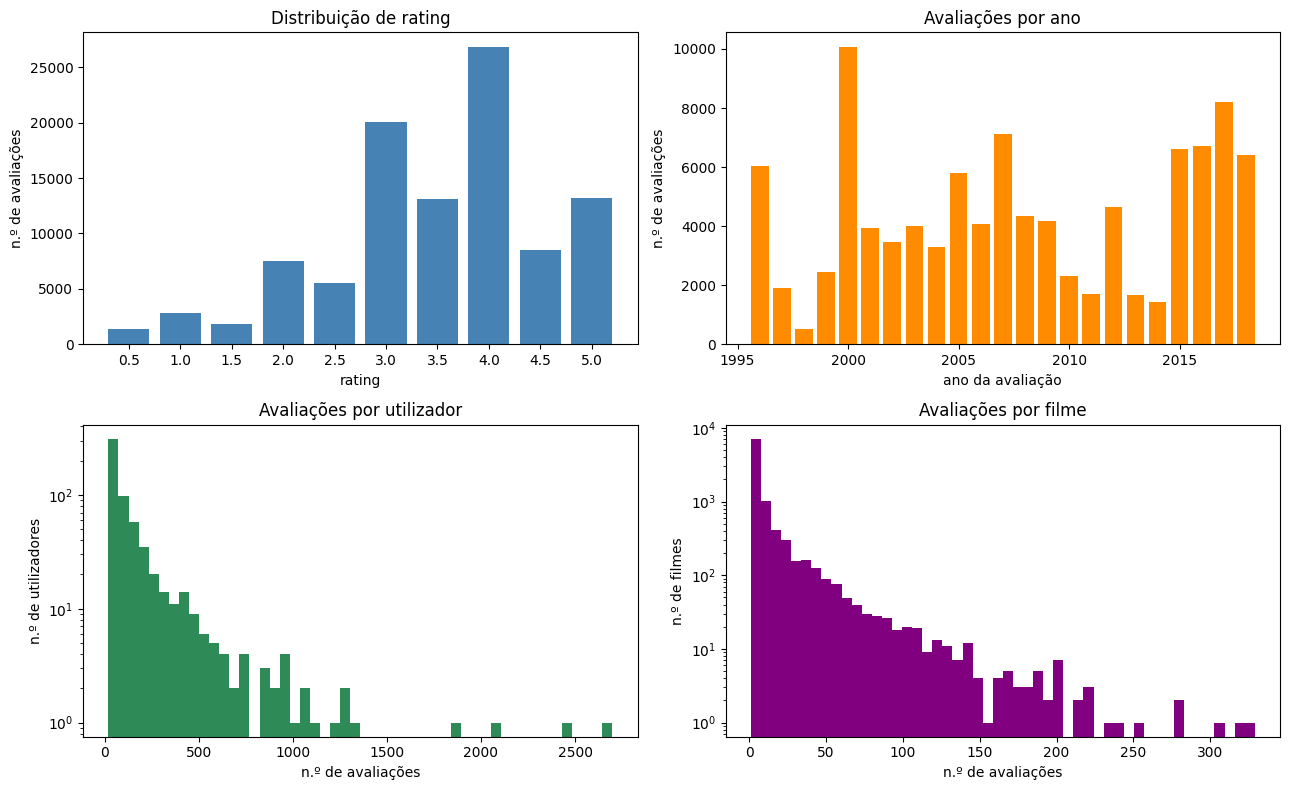

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# 1. rating: variável discreta -> gráfico de barras com a contagem de cada valor
rc = ratings.group_by('rating').len().sort('rating')
axes[0, 0].bar(rc['rating'].cast(pl.String), rc['len'], color='steelblue')
axes[0, 0].set(title='Distribuição de rating', xlabel='rating', ylabel='n.º de avaliações')

# 2. timestamp: avaliações por ano
ry = ratings_ext.group_by(pl.col('rated_at').dt.year().alias('ano')).len().sort('ano')
axes[0, 1].bar(ry['ano'], ry['len'], color='darkorange')
axes[0, 1].set(title='Avaliações por ano', xlabel='ano da avaliação', ylabel='n.º de avaliações')

# 3. n.º de avaliações por utilizador (cauda longa -> escala log)
per_user = ratings.group_by('userId').len()
axes[1, 0].hist(per_user['len'], bins=50, color='seagreen')
axes[1, 0].set(title='Avaliações por utilizador', xlabel='n.º de avaliações', ylabel='n.º de utilizadores', yscale='log')

# 4. n.º de avaliações por filme
per_movie = ratings.group_by('movieId').len()
axes[1, 1].hist(per_movie['len'], bins=50, color='purple')
axes[1, 1].set(title='Avaliações por filme', xlabel='n.º de avaliações', ylabel='n.º de filmes', yscale='log')

plt.tight_layout()
plt.show()

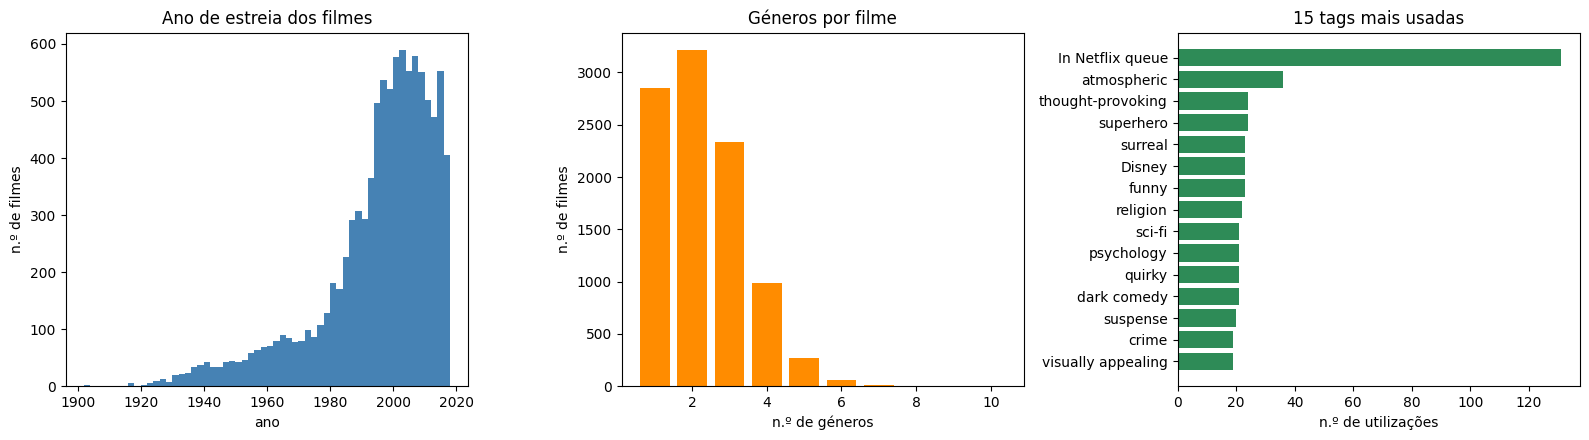

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 5. ano de estreia dos filmes
years = movies_ext['year'].drop_nulls()
axes[0].hist(years, bins=range(years.min(), years.max() + 2, 2), color='steelblue')
axes[0].set(title='Ano de estreia dos filmes', xlabel='ano', ylabel='n.º de filmes')

# 6. n.º de géneros por filme
ng = movies_ext.group_by('num_genres').len().sort('num_genres')
axes[1].bar(ng['num_genres'], ng['len'], color='darkorange')
axes[1].set(title='Géneros por filme', xlabel='n.º de géneros', ylabel='n.º de filmes')

# 7. tags mais usadas
top_tags = tags.group_by('tag').len().sort('len', descending=True).head(15).reverse()
axes[2].barh(top_tags['tag'], top_tags['len'], color='seagreen')
axes[2].set(title='15 tags mais usadas', xlabel='n.º de utilizações')

plt.tight_layout()
plt.show()

O que observar nos gráficos:

- Os valores **inteiros** de rating (3, 4, 5) são muito mais frequentes do que os meios pontos.
- Avaliações por utilizador e por filme têm **cauda longa**: poucos utilizadores/filmes concentram muitas
  avaliações. Por construção do dataset, cada utilizador tem pelo menos 20 avaliações.
- Muitos filmes têm muito poucas avaliações, o que vai ser importante na pergunta sobre a melhor média.

## 7. Perguntas sobre o dataset (Python e SQL)

Cada pergunta é respondida duas vezes, em **Polars** e em **DuckDB SQL**, e no fim confirma-se que
as duas respostas são iguais. A função `same()` compara duas tabelas ignorando diferenças de tipo
(`UInt32` vs `Int64`) e diferenças mínimas de arredondamento entre Polars e DuckDB.

In [30]:
from polars.testing import assert_frame_equal

def same(a: pl.DataFrame, b: pl.DataFrame, tol: float = 0.01) -> bool:
    try:
        assert_frame_equal(a, b, check_dtypes=False, abs_tol=tol)
        return True
    except AssertionError as e:
        print(e)
        return False

### 7.1 Quais são os géneros de filmes no dataset?

Reutilizamos `movie_genres` (secção 3), em que cada linha é um par (filme, género).
Em SQL, `string_split` + `unnest` faz o mesmo que `str.split` + `explode`.

In [31]:
# Python
genres_py = movie_genres.select('genre').unique().sort('genre')
print(genres_py.height, 'géneros (inclui "(no genres listed)")')
genres_py['genre'].to_list()

20 géneros (inclui "(no genres listed)")


['(no genres listed)',
 'Action',
 'Adventure',
 'Animation',
 'Children',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Fantasy',
 'Film-Noir',
 'Horror',
 'IMAX',
 'Musical',
 'Mystery',
 'Romance',
 'Sci-Fi',
 'Thriller',
 'War',
 'Western']

In [32]:
# SQL
genres_sql = duckdb.sql(f'''
    SELECT DISTINCT genre
    FROM (SELECT unnest(string_split(genres, '|')) AS genre FROM '{MOVIES}')
    ORDER BY genre
''').pl()
print('Python e SQL iguais:', same(genres_py, genres_sql))
genres_sql

Python e SQL iguais: True


genre
str
"""(no genres listed)"""
"""Action"""
"""Adventure"""
"""Animation"""
"""Children"""
…
"""Romance"""
"""Sci-Fi"""
"""Thriller"""


### 7.2 Qual é o número de filmes por género?

Como um filme pode ter vários géneros, a soma das contagens é maior do que o número de filmes.

In [33]:
# Python
movies_per_genre_py = (
    movie_genres
      .group_by('genre')
      .agg(pl.len().alias('num_movies'))
      .with_columns((pl.col('num_movies') / movies.height * 100).round(1).alias('pct_movies'))
      .sort(['num_movies', 'genre'], descending=[True, False])
)
print('Soma das contagens:', movies_per_genre_py['num_movies'].sum(), '| filmes:', movies.height)
movies_per_genre_py

Soma das contagens: 22084 | filmes: 9742


genre,num_movies,pct_movies
str,u32,f64
"""Drama""",4361,44.8
"""Comedy""",3756,38.6
"""Thriller""",1894,19.4
"""Action""",1828,18.8
"""Romance""",1596,16.4
…,…,…
"""Musical""",334,3.4
"""Western""",167,1.7
"""IMAX""",158,1.6


In [34]:
# SQL
movies_per_genre_sql = duckdb.sql(f'''
    WITH movie_genre AS (
        SELECT movieId, unnest(string_split(genres, '|')) AS genre
        FROM '{MOVIES}'
    )
    SELECT genre,
           COUNT(*)                                                  AS num_movies,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM '{MOVIES}'), 1) AS pct_movies
    FROM movie_genre
    GROUP BY genre
    ORDER BY num_movies DESC, genre
''').pl()
print('Python e SQL iguais:', same(movies_per_genre_py.select('genre', 'num_movies'),
                                    movies_per_genre_sql.select('genre', 'num_movies')))
movies_per_genre_sql

Python e SQL iguais: True


genre,num_movies,pct_movies
str,i64,f64
"""Drama""",4361,44.8
"""Comedy""",3756,38.6
"""Thriller""",1894,19.4
"""Action""",1828,18.8
"""Romance""",1596,16.4
…,…,…
"""Musical""",334,3.4
"""Western""",167,1.7
"""IMAX""",158,1.6


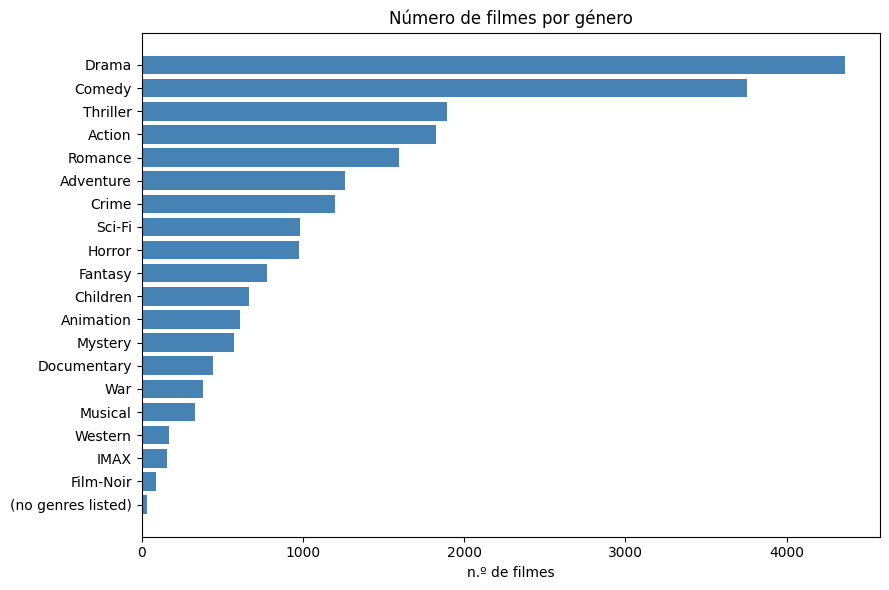

In [35]:
plot_df = movies_per_genre_py.reverse()
plt.figure(figsize=(9, 6))
plt.barh(plot_df['genre'], plot_df['num_movies'], color='steelblue')
plt.title('Número de filmes por género')
plt.xlabel('n.º de filmes')
plt.tight_layout()
plt.show()

### 7.3 Qual é a distribuição das avaliações por utilizador?

Olhamos para isto de duas formas:

1. **Resumo por utilizador**: quantas avaliações fez, média, desvio-padrão, mínimo, mediana e máximo.
2. **Distribuição dos valores de rating por utilizador**: quantas vezes cada utilizador deu 0.5, 1.0, …, 5.0.

In [36]:
# Python: resumo por utilizador
user_stats_py = (
    ratings
      .group_by('userId')
      .agg(
          pl.len().alias('num_ratings'),
          pl.col('rating').mean().round(3).alias('mean'),
          pl.col('rating').std().round(3).alias('std'),
          pl.col('rating').min().alias('min'),
          pl.col('rating').median().alias('median'),
          pl.col('rating').max().alias('max'),
      )
      .sort('userId')
)
user_stats_py

userId,num_ratings,mean,std,min,median,max
i64,u32,f64,f64,f64,f64,f64
1,232,4.366,0.8,1.0,5.0,5.0
2,29,3.948,0.806,2.0,4.0,5.0
3,39,2.436,2.091,0.5,0.5,5.0
4,216,3.556,1.314,1.0,4.0,5.0
5,44,3.636,0.99,1.0,4.0,5.0
…,…,…,…,…,…,…
606,1115,3.657,0.724,0.5,4.0,5.0
607,187,3.786,0.966,1.0,4.0,5.0
608,831,3.134,1.079,0.5,3.0,5.0


In [37]:
# SQL: o mesmo resumo
user_stats_sql = duckdb.sql(f'''
    SELECT userId,
           COUNT(*)                         AS num_ratings,
           ROUND(AVG(rating), 3)            AS mean,
           ROUND(STDDEV_SAMP(rating), 3)    AS std,
           MIN(rating)                      AS min,
           MEDIAN(rating)                   AS median,
           MAX(rating)                      AS max
    FROM '{RATINGS}'
    GROUP BY userId
    ORDER BY userId
''').pl()
print('Python e SQL iguais:', same(user_stats_py, user_stats_sql))
user_stats_sql

Python e SQL iguais: True


userId,num_ratings,mean,std,min,median,max
i64,i64,f64,f64,f64,f64,f64
1,232,4.366,0.8,1.0,5.0,5.0
2,29,3.948,0.806,2.0,4.0,5.0
3,39,2.436,2.091,0.5,0.5,5.0
4,216,3.556,1.314,1.0,4.0,5.0
5,44,3.636,0.99,1.0,4.0,5.0
…,…,…,…,…,…,…
606,1115,3.657,0.724,0.5,4.0,5.0
607,187,3.786,0.966,1.0,4.0,5.0
608,831,3.134,1.079,0.5,3.0,5.0


In [38]:
# Como se distribuem estas estatísticas pelos utilizadores?
user_stats_py.select('num_ratings', 'mean', 'std', 'median').describe()

statistic,num_ratings,mean,std,median
str,f64,f64,f64,f64
"""count""",610.0,610.0,610.0,610.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",165.304918,3.657225,0.927126,3.760246
"""std""",269.480584,0.480651,0.266101,0.60172
"""min""",20.0,1.275,0.0,0.5
"""25%""",35.0,3.36,0.736,3.5
"""50%""",71.0,3.696,0.902,4.0
"""75%""",168.0,4.0,1.079,4.0
"""max""",2698.0,5.0,2.091,5.0


In [39]:
# Python: contagem de cada valor de rating por utilizador (formato largo)
rating_dist_py = (
    ratings
      .pivot(on='rating', index='userId', values='rating', aggregate_function='len', sort_columns=True)
      .fill_null(0)
      .sort('userId')
)
rating_dist_py.head(10)

userId,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0
i64,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
1,0,1,0,5,0,26,0,76,0,124
2,0,0,0,1,1,4,4,9,4,6
3,20,0,0,1,0,1,1,1,5,10
4,0,23,0,26,0,39,0,64,0,64
5,0,1,0,3,0,17,0,13,0,10
6,0,7,0,13,0,152,0,102,0,40
7,6,12,12,11,7,16,18,28,29,13
8,0,1,0,3,0,21,0,12,0,10
9,0,6,0,6,0,12,0,14,0,8


In [40]:
# SQL: PIVOT faz o mesmo
rating_dist_sql = duckdb.sql(f'''
    PIVOT (SELECT userId, rating FROM '{RATINGS}')
    ON rating
    USING COUNT(*)
    GROUP BY userId
    ORDER BY userId
''').pl()
rating_dist_sql.head(10)

userId,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
1,0,1,0,5,0,26,0,76,0,124
2,0,0,0,1,1,4,4,9,4,6
3,20,0,0,1,0,1,1,1,5,10
4,0,23,0,26,0,39,0,64,0,64
5,0,1,0,3,0,17,0,13,0,10
6,0,7,0,13,0,152,0,102,0,40
7,6,12,12,11,7,16,18,28,29,13
8,0,1,0,3,0,21,0,12,0,10
9,0,6,0,6,0,12,0,14,0,8


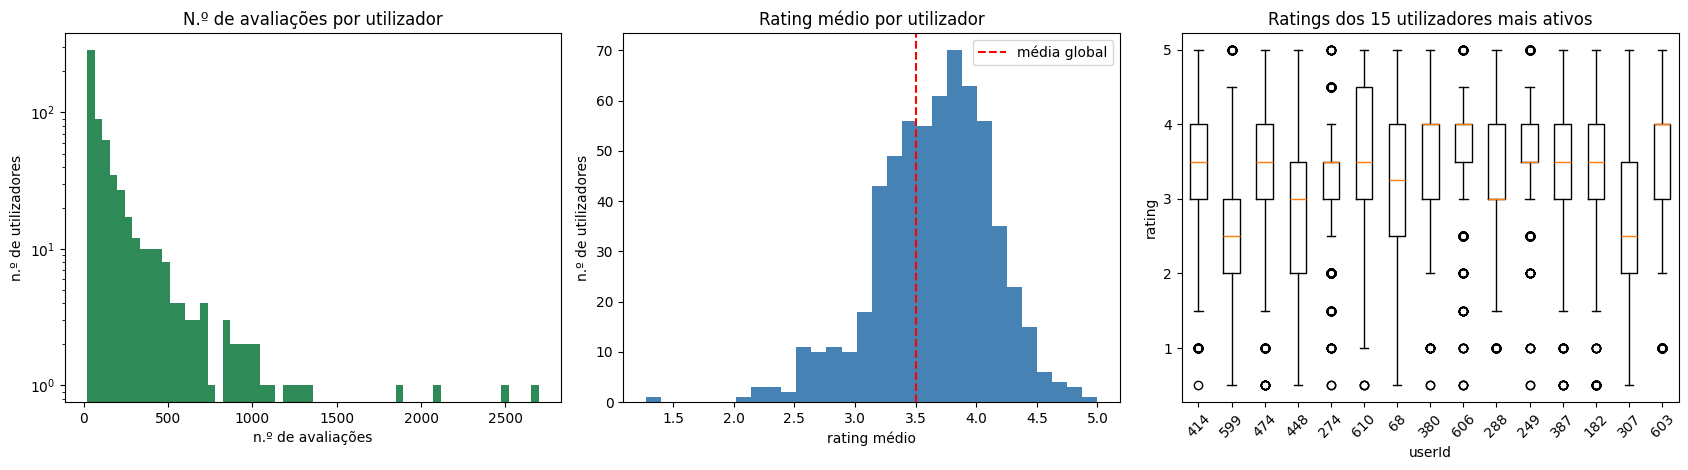

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

# a) n.º de avaliações por utilizador
axes[0].hist(user_stats_py['num_ratings'], bins=60, color='seagreen')
axes[0].set(title='N.º de avaliações por utilizador', xlabel='n.º de avaliações',
            ylabel='n.º de utilizadores', yscale='log')

# b) rating médio por utilizador
axes[1].hist(user_stats_py['mean'], bins=30, color='steelblue')
axes[1].axvline(ratings['rating'].mean(), color='red', ls='--', label='média global')
axes[1].set(title='Rating médio por utilizador', xlabel='rating médio', ylabel='n.º de utilizadores')
axes[1].legend()

# c) boxplot dos 15 utilizadores mais ativos
top_users = user_stats_py.sort('num_ratings', descending=True).head(15)['userId'].to_list()
data = [ratings.filter(pl.col('userId') == u)['rating'].to_numpy() for u in top_users]
axes[2].boxplot(data, tick_labels=[str(u) for u in top_users])
axes[2].set(title='Ratings dos 15 utilizadores mais ativos', xlabel='userId', ylabel='rating')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2341/1063613393.py:4: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  heat = (rating_dist_py.filter(pl.col('userId').is_in(top20))


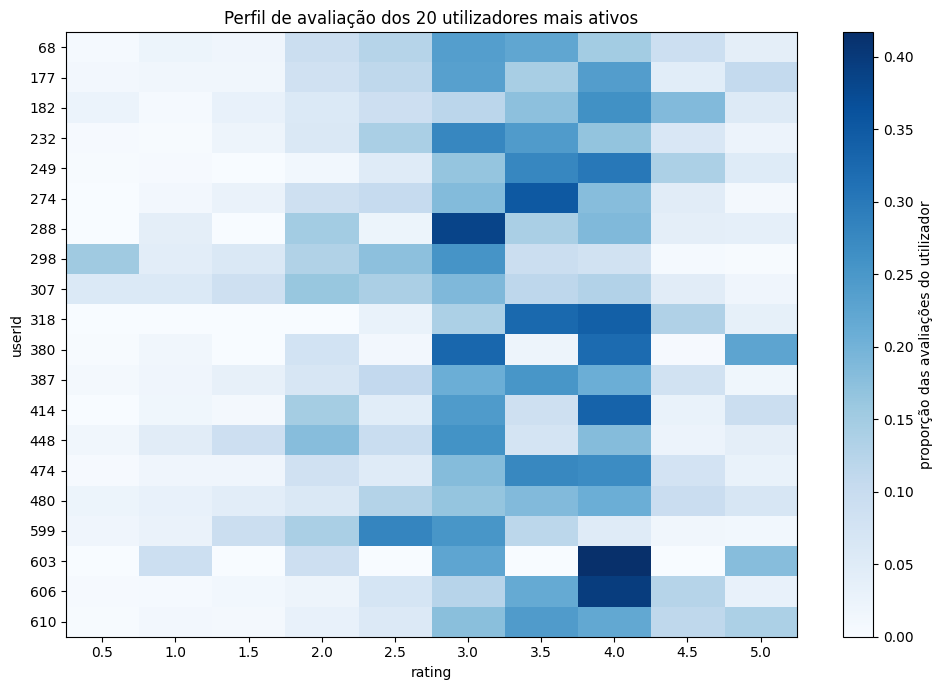

In [42]:
# Heatmap: proporção de cada valor de rating nos 20 utilizadores mais ativos
top20 = user_stats_py.sort('num_ratings', descending=True).head(20)['userId']
value_cols = [c for c in rating_dist_py.columns if c != 'userId']
heat = (rating_dist_py.filter(pl.col('userId').is_in(top20))
        .with_columns(total=pl.sum_horizontal(value_cols))
        .with_columns([pl.col(c) / pl.col('total') for c in value_cols]))

plt.figure(figsize=(10, 7))
plt.imshow(heat.select(value_cols).to_numpy(), aspect='auto', cmap='Blues')
plt.colorbar(label='proporção das avaliações do utilizador')
plt.xticks(range(len(value_cols)), value_cols)
plt.yticks(range(heat.height), heat['userId'].to_list())
plt.xlabel('rating')
plt.ylabel('userId')
plt.title('Perfil de avaliação dos 20 utilizadores mais ativos')
plt.tight_layout()
plt.show()

O heatmap mostra que os utilizadores têm **perfis diferentes**: uns usam toda a escala, outros só valores
inteiros, outros concentram-se em notas altas. É por isso que, em sistemas de recomendação, é comum
normalizar os ratings por utilizador (subtrair a média de cada um).

### 7.4 Quais são os filmes com a média de avaliação mais alta?

Sem um número mínimo de avaliações, o topo fica cheio de filmes com **uma única avaliação de 5.0**.
Por isso, como na secção 2, exigimos pelo menos 100 avaliações.

In [43]:
# O problema: sem mínimo de avaliações
naive = (ratings.group_by('movieId')
         .agg(pl.col('rating').mean().alias('avg_rating'), pl.len().alias('num_ratings'))
         .sort('avg_rating', descending=True))
print('Filmes com média 5.0:', naive.filter(pl.col('avg_rating') == 5).height,
      '| dos quais com 1 só avaliação:', naive.filter((pl.col('avg_rating') == 5) & (pl.col('num_ratings') == 1)).height)
naive.join(movies.select('movieId', 'title'), on='movieId').head(10)

Filmes com média 5.0: 296 | dos quais com 1 só avaliação: 289


movieId,avg_rating,num_ratings,title
i64,f64,u32,str
1,3.92093,215,"""Toy Story (1995)"""
2,3.431818,110,"""Jumanji (1995)"""
3,3.259615,52,"""Grumpier Old Men (1995)"""
4,2.357143,7,"""Waiting to Exhale (1995)"""
5,3.071429,49,"""Father of the Bride Part II (1…"
6,3.946078,102,"""Heat (1995)"""
7,3.185185,54,"""Sabrina (1995)"""
8,2.875,8,"""Tom and Huck (1995)"""
9,3.125,16,"""Sudden Death (1995)"""


In [44]:
# Python: top 10 com pelo menos 100 avaliações
MIN_RATINGS = 100

top10_py = (
    ratings
      .join(movies.select('movieId', 'title'), on='movieId')
      .group_by('movieId', 'title')
      .agg(pl.col('rating').mean().alias('avg_exact'), pl.len().alias('num_ratings'))
      .filter(pl.col('num_ratings') >= MIN_RATINGS)
      .sort('avg_exact', descending=True)
      .head(10)
      .select('title', pl.col('avg_exact').round(2).alias('avg_rating'), 'num_ratings')
)
top10_py

title,avg_rating,num_ratings
str,f64,u32
"""Shawshank Redemption, The (199…",4.43,317
"""Godfather, The (1972)""",4.29,192
"""Fight Club (1999)""",4.27,218
"""Godfather: Part II, The (1974)""",4.26,129
"""Departed, The (2006)""",4.25,107
"""Goodfellas (1990)""",4.25,126
"""Casablanca (1942)""",4.24,100
"""Dark Knight, The (2008)""",4.24,149
"""Usual Suspects, The (1995)""",4.24,204


In [45]:
# SQL: é a query da secção 2 (top10); confirmamos que coincide com Polars
print('Python e SQL iguais:', same(top10_py, top10))
top10

Python e SQL iguais: True


title,avg_rating,num_ratings
str,f64,i64
"""Shawshank Redemption, The (199…",4.43,317
"""Godfather, The (1972)""",4.29,192
"""Fight Club (1999)""",4.27,218
"""Godfather: Part II, The (1974)""",4.26,129
"""Departed, The (2006)""",4.25,107
"""Goodfellas (1990)""",4.25,126
"""Casablanca (1942)""",4.24,100
"""Dark Knight, The (2008)""",4.24,149
"""Usual Suspects, The (1995)""",4.24,204


**Extra: média ponderada (Bayesiana).** Em vez de um corte rígido, puxa-se a média de cada filme para a
média global, com mais força quando há poucas avaliações (fórmula usada pelo IMDb):

$$WR = \frac{v}{v+m}\,R + \frac{m}{v+m}\,C$$

onde $R$ é a média do filme, $v$ o n.º de avaliações, $C$ a média global e $m$ o "peso" da média global.

In [46]:
# Python
C = ratings['rating'].mean()
m = MIN_RATINGS

weighted_py = (
    ratings.group_by('movieId')
      .agg(pl.col('rating').mean().alias('R'), pl.len().alias('v'))
      .with_columns(((pl.col('v') / (pl.col('v') + m)) * pl.col('R')
                     + (m / (pl.col('v') + m)) * C).alias('weighted'))
      .join(movies.select('movieId', 'title'), on='movieId')
      .sort('weighted', descending=True)
      .head(10)
      .select('title', pl.col('R').round(2).alias('avg_rating'), pl.col('v').alias('num_ratings'),
              pl.col('weighted').round(3))
)
weighted_py

title,avg_rating,num_ratings,weighted
str,f64,u32,f64
"""Shawshank Redemption, The (199…",4.43,317,4.207
"""Fight Club (1999)""",4.27,218,4.03
"""Pulp Fiction (1994)""",4.2,307,4.026
"""Star Wars: Episode IV - A New …",4.23,251,4.023
"""Godfather, The (1972)""",4.29,192,4.019
"""Forrest Gump (1994)""",4.16,329,4.01
"""Matrix, The (1999)""",4.19,278,4.01
"""Schindler's List (1993)""",4.22,220,3.999
"""Usual Suspects, The (1995)""",4.24,204,3.996


In [47]:
# SQL
weighted_sql = duckdb.sql(f'''
    WITH stats AS (
        SELECT movieId, AVG(rating) AS R, COUNT(*) AS v
        FROM '{RATINGS}' GROUP BY movieId
    ),
    params AS (SELECT AVG(rating) AS C, {m} AS m FROM '{RATINGS}')
    SELECT mv.title,
           ROUND(s.R, 2)                                          AS avg_rating,
           s.v                                                    AS num_ratings,
           ROUND(s.v / (s.v + p.m) * s.R + p.m / (s.v + p.m) * p.C, 3) AS weighted
    FROM stats s
    CROSS JOIN params p
    JOIN '{MOVIES}' mv USING (movieId)
    ORDER BY weighted DESC
    LIMIT 10
''').pl()
print('Python e SQL iguais:', same(weighted_py, weighted_sql))
weighted_sql

DataFrames are different (value mismatch for column "title")
[left]: shape: (10,)
Series: 'title' [str]
[
	"Shawshank Redemption, The (199…
	"Fight Club (1999)"
	"Pulp Fiction (1994)"
	"Star Wars: Episode IV - A New …
	"Godfather, The (1972)"
	"Forrest Gump (1994)"
	"Matrix, The (1999)"
	"Schindler's List (1993)"
	"Usual Suspects, The (1995)"
	"Silence of the Lambs, The (199…
]
[right]: shape: (10,)
Series: 'title' [str]
[
	"Shawshank Redemption, The (199…
	"Fight Club (1999)"
	"Pulp Fiction (1994)"
	"Star Wars: Episode IV - A New …
	"Godfather, The (1972)"
	"Matrix, The (1999)"
	"Forrest Gump (1994)"
	"Schindler's List (1993)"
	"Usual Suspects, The (1995)"
	"Silence of the Lambs, The (199…
]
Python e SQL iguais: False


title,avg_rating,num_ratings,weighted
str,f64,i64,f64
"""Shawshank Redemption, The (199…",4.43,317,4.207
"""Fight Club (1999)""",4.27,218,4.03
"""Pulp Fiction (1994)""",4.2,307,4.026
"""Star Wars: Episode IV - A New …",4.23,251,4.023
"""Godfather, The (1972)""",4.29,192,4.019
"""Matrix, The (1999)""",4.19,278,4.01
"""Forrest Gump (1994)""",4.16,329,4.01
"""Schindler's List (1993)""",4.22,220,3.999
"""Usual Suspects, The (1995)""",4.24,204,3.996


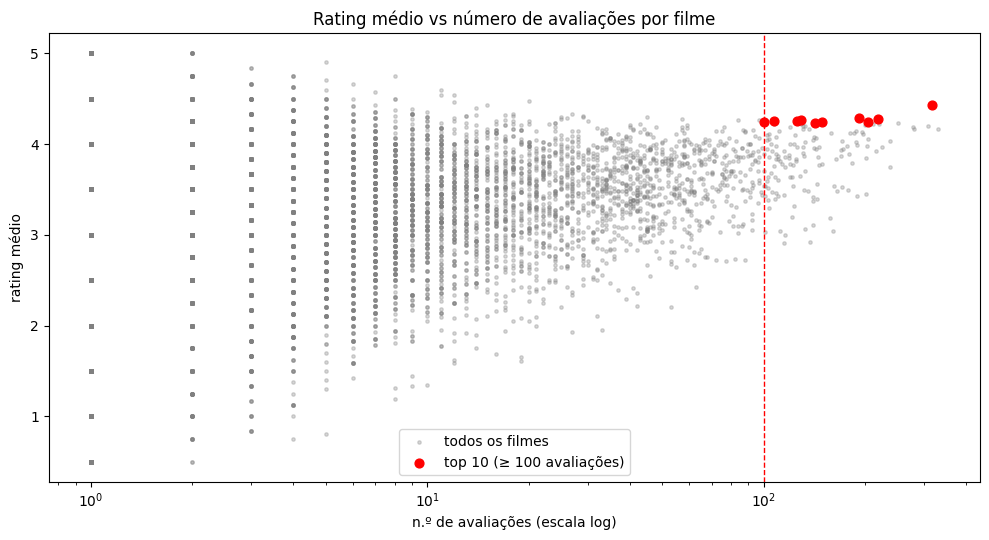

In [48]:
# Média vs n.º de avaliações: os extremos (0.5 e 5.0) vêm quase todos de filmes com poucas avaliações
plt.figure(figsize=(10, 5.5))
plt.scatter(naive['num_ratings'], naive['avg_rating'], s=6, alpha=0.3, color='grey', label='todos os filmes')
top_ids = (naive.filter(pl.col('num_ratings') >= MIN_RATINGS).head(10))
plt.scatter(top_ids['num_ratings'], top_ids['avg_rating'], s=40, color='red', label=f'top 10 (≥ {MIN_RATINGS} avaliações)')
plt.axvline(MIN_RATINGS, color='red', ls='--', lw=1)
plt.xscale('log')
plt.xlabel('n.º de avaliações (escala log)')
plt.ylabel('rating médio')
plt.title('Rating médio vs número de avaliações por filme')
plt.legend()
plt.tight_layout()
plt.show()

## Download the results

Files in a Colab session are deleted when it ends. This cell downloads the `parquet/` and `output/`
folders as a zip file.

In [49]:
import shutil
shutil.copytree(PQ_DIR, OUT_DIR / 'parquet', dirs_exist_ok=True)
zip_file = shutil.make_archive('lab_results', 'zip', OUT_DIR)
try:
    from google.colab import files
    files.download(zip_file)
except ImportError:
    print('Not running in Colab: the files are in', OUT_DIR.resolve())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>